# Getting Started with Netlist Carpentry
This notebook shows you the basic workflow of Netlist Carpentry: **read** a Verilog design, **inspect** its contents, and **write** it back. By the end, you'll have visualized your first netlist.

> **Prerequisites**: Python 3.9+ with `netlist-carpentry` installed. See the [Installation Guide](installation.md) for setup instructions.

In [1]:
import netlist_carpentry

print(f"Netlist Carpentry {netlist_carpentry.__version__} is ready!")

Netlist Carpentry 0.5.3 is ready!


## About Yosys
Netlist Carpentry uses [Yosys](https://github.com/YosysHQ/yosys) to synthesize Verilog into a generic netlist. If Yosys is not installed or the system does not understand the command 'yosys', the package falls back to `yowasp-yosys` (a bundled version) automatically.

## Reading a Verilog Design
Load a Verilog file into a [Circuit](../src/netlist_carpentry/core/circuit.py) object. Netlist Carpentry uses Yosys internally to synthesize the design.

<div class="admonition info alert alert-info">
  <strong>Info:</strong> By default, Yosys output is suppressed. Pass <b>verbose=True</b> to <b>netlist_carpentry.read()</b> to see the synthesis log.
</div>

In [2]:
circuit = netlist_carpentry.read("files/simpleAdder.v", top="simpleAdder", circuit_name="Adder Circuit")
print(f"Loaded circuit '{circuit.name}' with {circuit.module_count} module(s).")

Loaded circuit 'Adder Circuit' with 1 module(s).


## Inspecting the Circuit
A circuit is a collection of modules. The **top module** is the entry point — everything else is nested inside it.

In [3]:
# List all modules
for name in circuit.modules:
    mod = circuit.get_module(name)
    print(f"  Module '{name}': {len(mod.instances)} instances, {len(mod.ports)} ports, {len(mod.wires)} wires")

print(f"\nTop module: '{circuit.top_name}'")

  Module 'simpleAdder': 4 instances, 6 ports, 8 wires

Top module: 'simpleAdder'


## Visualize Your First Netlist
Netlist Carpentry can render a graph of any module, both as a static plot and a interactive widget.
This gives you an instant visual understanding of the circuit structure.
In the plot, the layout might be a bit stretched occasionally, though.

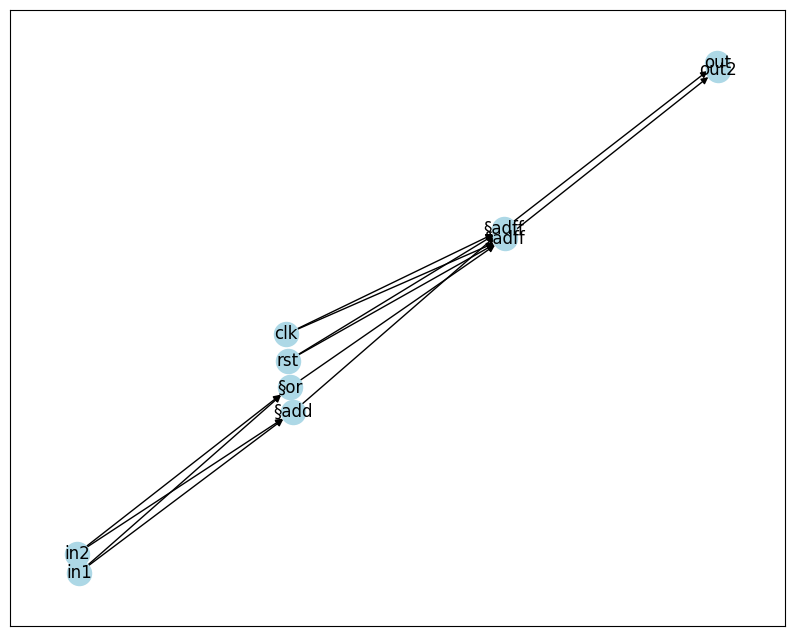

In [4]:
circuit.top.show()

An static graph image of the adder module should appear above, showing all instances (gates) and their connections.

## Writing Back to Verilog
Any loaded circuit can be written back to a Verilog file:

In [5]:
circuit.write("output/adder_output.v", overwrite=True)
print("Wrote Verilog file 'output/adder_output.v'")

Wrote Verilog file 'output/adder_output.v'


## What's Next?
You've read, inspected, visualized, and written a netlist. Here's where to go next:

| Notebook | Topic |
|----------|-------|
| [02 Accessing Circuit Data](02_access_circuit_data.ipynb) | Deep dive into modules, instances, ports, and wires |
| [03 Circuit Search](03_circuit_search.ipynb) | Find specific elements in your netlist |
| [04 Circuit Modification](04_circuit_modification.ipynb) | Add, remove, and change circuit elements |
| [05 Module Graphs](05_module_graphs.ipynb) | Work with directed graphs of module structure |
| [06 Graph Visualization](06_graph_visualization.ipynb) | Advanced visualization with NetworkX and matplotlib |
| [07 Pattern Matching](07_pattern_matching.ipynb) | Match complex patterns in your netlist |
| [08 Pattern Replacement](08_pattern_replacement.ipynb) | Replace matched patterns with new implementations |
| [09 Equivalence Checking](09_equivalence_checking.ipynb) | Verify that two circuits behave identically |
| [12 Gate Chain Optimizer](12_gate_chain_optimizer.ipynb) | Optimize gate chains automatically |